<a href="https://colab.research.google.com/github/FrankFayz/ML_PROJECT/blob/Feauture%2FAsinja_Andrew's_branch/MACHINE_LEARNING_ASSIGNMENT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# The problem is the lack of transparent and data-driven house pricing, which can leave buyers and
# sellers heavily dependent on intermediaries whose price estimates may be inconsistent or unreliable.
# This project develops a machine learning model that predicts house prices from property
# characteristics, providing an objective reference that can support more informed and transparent
# property transactions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Libraries Imported

In [ ]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('/content/House_Price_Prediction_Dataset.csv')

# Display the first 5 rows of the DataFrame to inspect the data
display(df.head())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360.0,5.0,4.0,3.0,1970.0,Downtown,Excellent,No,149919.0
1,2,4272.0,5.0,4.0,3.0,1958.0,Downtown,Excellent,No,424998.0
2,3,3592.0,2.0,2.0,3.0,1938.0,Downtown,Good,No,266746.0
3,4,966.0,4.0,2.0,2.0,1902.0,Suburban,Fair,Yes,244020.0
4,5,4926.0,1.0,4.0,2.0,1975.0,Downtown,Fair,Yes,636056.0


In [ ]:
df.tail()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
2035,1016,3157.0,5.0,3.0,2.0,2001.0,Suburban,Excellent,No,638085.0
2036,1017,4298.0,3.0,2.0,1.0,1903.0,Rural,Good,No,101798.0
2037,1018,1304.0,1.0,1.0,2.0,2005.0,Urban,Good,Yes,722010.0
2038,1019,574.0,4.0,3.0,2.0,1981.0,Downtown,Fair,No,469230.0
2039,1020,2675.0,3.0,1.0,2.0,2007.0,Suburban,Excellent,No,650709.0


In [ ]:
df.dtypes

,0
Id,int64
Area,float64
Bedrooms,float64
Bathrooms,float64
Floors,float64
YearBuilt,float64
Location,object
Condition,object
Garage,object
Price,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2040 entries, 0 to 2039
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Id         2040 non-null   int64  
 1   Area       2038 non-null   float64
 2   Bedrooms   2037 non-null   float64
 3   Bathrooms  2038 non-null   float64
 4   Floors     2037 non-null   float64
 5   YearBuilt  2039 non-null   float64
 6   Location   2036 non-null   object 
 7   Condition  2038 non-null   object 
 8   Garage     2038 non-null   object 
 9   Price      2039 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 159.5+ KB


In [ ]:
df.shape

(2040, 10)

In [ ]:
df.isnull().sum()

,0
Id,0
Area,2
Bedrooms,3
Bathrooms,2
Floors,3
YearBuilt,1
Location,4
Condition,2
Garage,2
Price,1


In [ ]:
# Impute numerical columns with their median
for col in ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt','Price']:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled missing values in '{col}' with median: {median_val}")

Filled missing values in 'Area' with median: 2834.5
Filled missing values in 'Bedrooms' with median: 3.0
Filled missing values in 'Bathrooms' with median: 3.0
Filled missing values in 'Floors' with median: 2.0
Filled missing values in 'YearBuilt' with median: 1961.0
Filled missing values in 'Price' with median: 538720.0


/tmp/ipykernel_1217/2597325963.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [ ]:
# Impute categorical columns with their mode
for col in ['Location', 'Condition', 'Garage']:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        # .mode() can return multiple values, so take the first
        df[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in '{col}' with mode: {mode_val}")

Filled missing values in 'Location' with mode: Downtown
Filled missing values in 'Condition' with mode: Fair
Filled missing values in 'Garage' with mode: No


/tmp/ipykernel_1217/2371470642.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
# Check for duplicate rows in the DataFrame
df.duplicated().sum()

np.int64(18)

In [ ]:
print(df[df.duplicated()])

        Id    Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  \
2022  1003  3780.0       3.0        4.0     3.0     1956.0  Suburban   
2023  1004  3073.0       1.0        3.0     3.0     1936.0     Urban   
2024  1005  3099.0       1.0        2.0     3.0     1997.0  Suburban   
2025  1006  4533.0       3.0        2.0     1.0     1906.0  Suburban   
2026  1007   736.0       3.0        2.0     3.0     1939.0  Downtown   
2027  1008  1804.0       1.0        2.0     1.0     1991.0     Urban   
2028  1009  3930.0       3.0        2.0     2.0     1938.0  Suburban   
2029  1010  1801.0       2.0        1.0     2.0     1961.0     Rural   
2030  1011  3041.0       4.0        1.0     3.0     2002.0  Suburban   
2031  1012  2551.0       4.0        1.0     1.0     1991.0     Rural   
2032  1013   941.0       4.0        3.0     2.0     1977.0     Rural   
2033  1014  2576.0       2.0        4.0     1.0     1952.0     Urban   
2034  1015  3680.0       3.0        2.0     1.0     2013.0     R

In [ ]:
# Remove duplicate rows from the DataFrame, keeping the first occurrence
df.drop_duplicates(inplace=True)
print("Duplicate rows removed.")

# Display the new shape of the DataFrame
df.shape


Duplicate rows removed.


(2022, 10)

In [ ]:
# Re-check for duplicate rows to confirm removal
duplicate_rows_after_removal = df.duplicated().sum()
df.duplicated().sum()

np.int64(0)

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360.0,5.0,4.0,3.0,1970.0,Downtown,Excellent,No,149919.0
1,2,4272.0,5.0,4.0,3.0,1958.0,Downtown,Excellent,No,424998.0
2,3,3592.0,2.0,2.0,3.0,1938.0,Downtown,Good,No,266746.0
3,4,966.0,4.0,2.0,2.0,1902.0,Suburban,Fair,Yes,244020.0
4,5,4926.0,1.0,4.0,2.0,1975.0,Downtown,Fair,Yes,636056.0


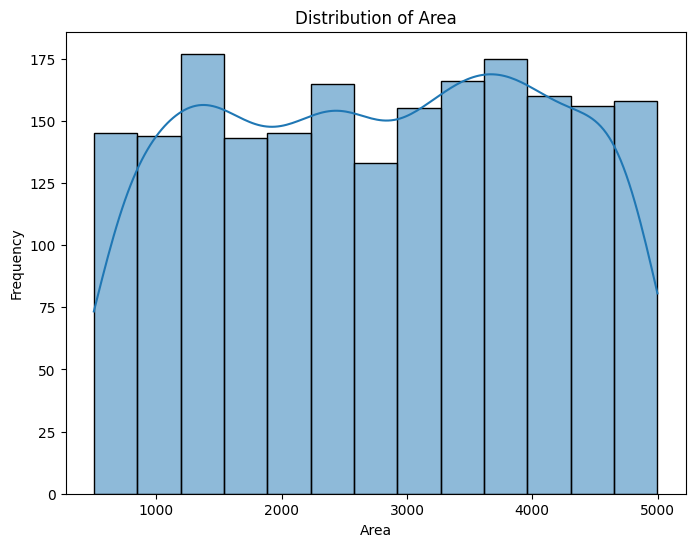

In [ ]:
#Distribution of Bedrooms
plt.figure(figsize=(8, 6))
sns.histplot(df['Area'], kde=True)
plt.title('Distribution of Area')
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.show()

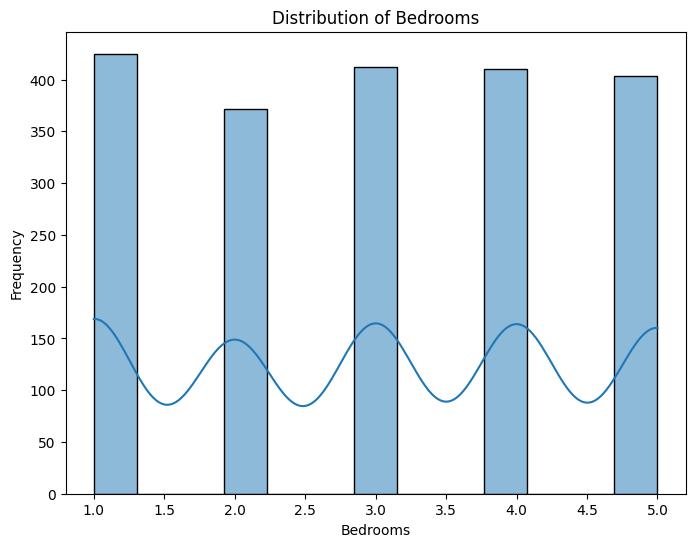

In [ ]:
#Distribution of Bathrooms
plt.figure(figsize=(8, 6))
sns.histplot(df['Bedrooms'], kde=True)
plt.title('Distribution of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Frequency')
plt.show()

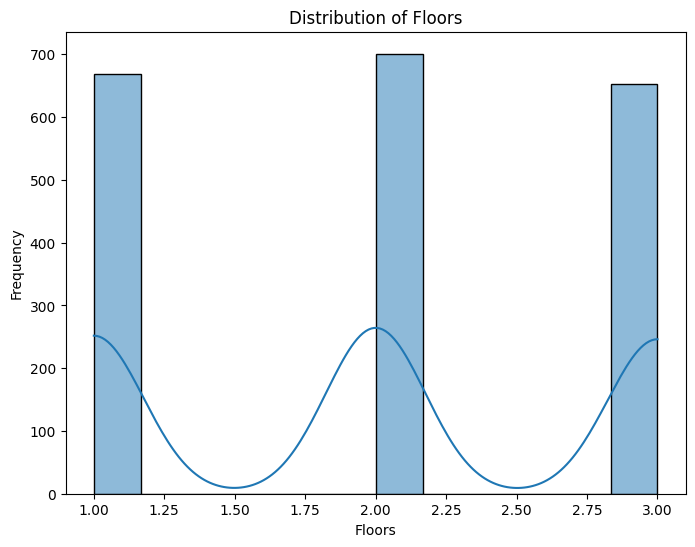

In [ ]:
#Distribution of Floors
plt.figure(figsize=(8, 6))
sns.histplot(df['Floors'], kde=True)
plt.title('Distribution of Floors')
plt.xlabel('Floors')
plt.ylabel('Frequency')
plt.show()

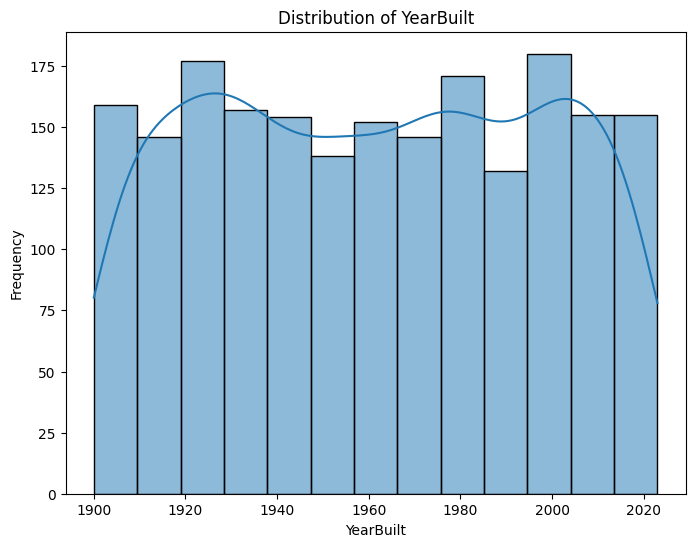

In [ ]:
#Distribution of 'YearBuilt'
plt.figure(figsize=(8, 6))
sns.histplot(df['YearBuilt'], kde=True)
plt.title('Distribution of YearBuilt')
plt.xlabel('YearBuilt')
plt.ylabel('Frequency')
plt.show()

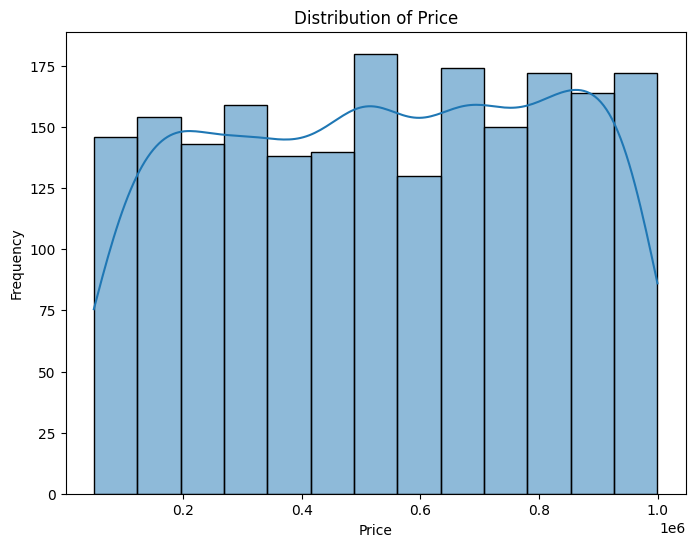

In [ ]:
#Distribution of 'Price'
plt.figure(figsize=(8, 6))
sns.histplot(df['Price'], kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [ ]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

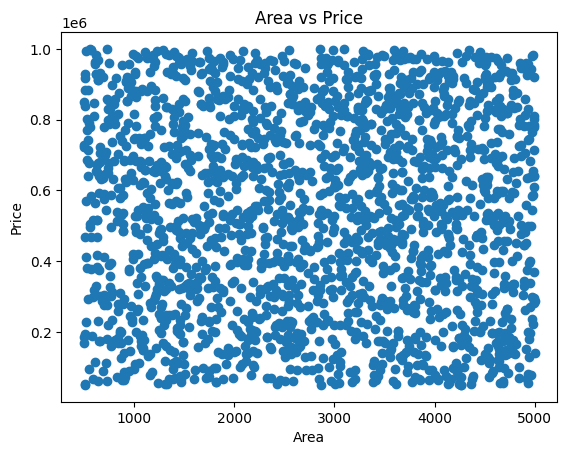

In [ ]:
plt.scatter(df['Area'], df['Price'])
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.show()

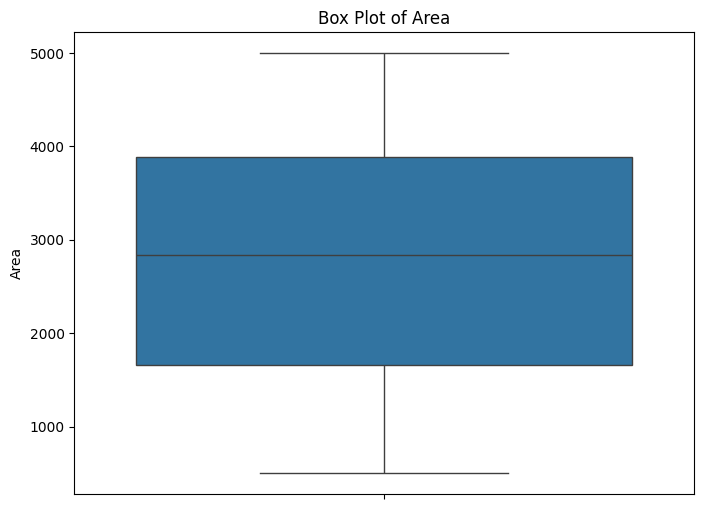

In [ ]:
#BoxPlot for area
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Area'])
plt.title('Box Plot of Area')
plt.ylabel('Area')
plt.show()

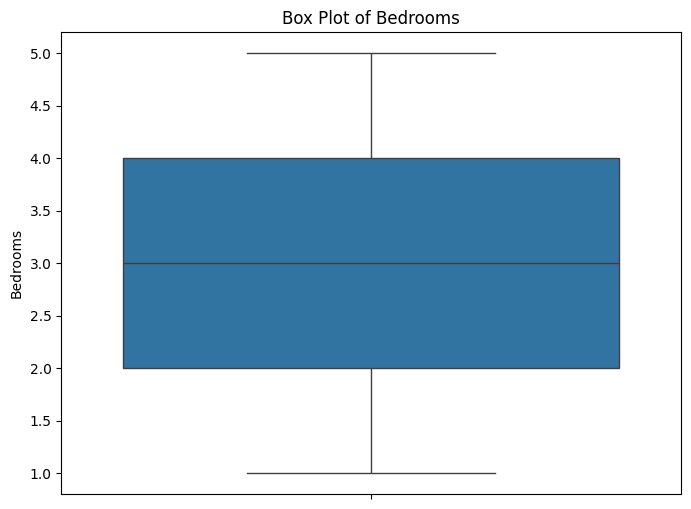

In [ ]:
#Box Plot for Bedrooms
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Bedrooms'])
plt.title('Box Plot of Bedrooms')
plt.ylabel('Bedrooms')
plt.show()

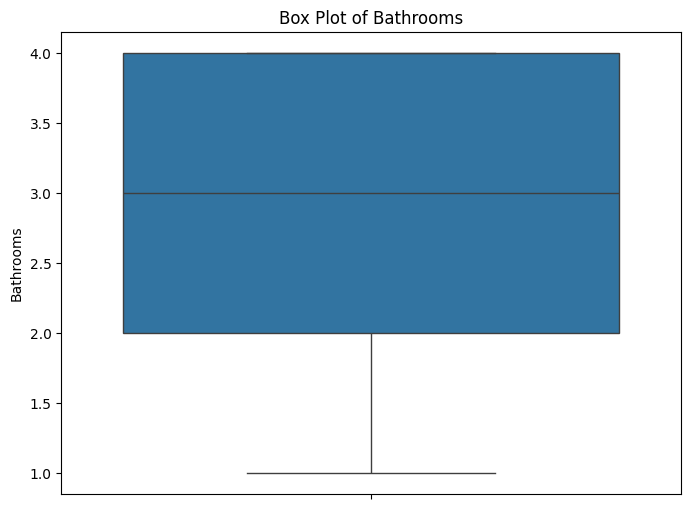

In [ ]:
#Box Plot for Bathrooms
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Bathrooms'])
plt.title('Box Plot of Bathrooms')
plt.ylabel('Bathrooms')
plt.show()

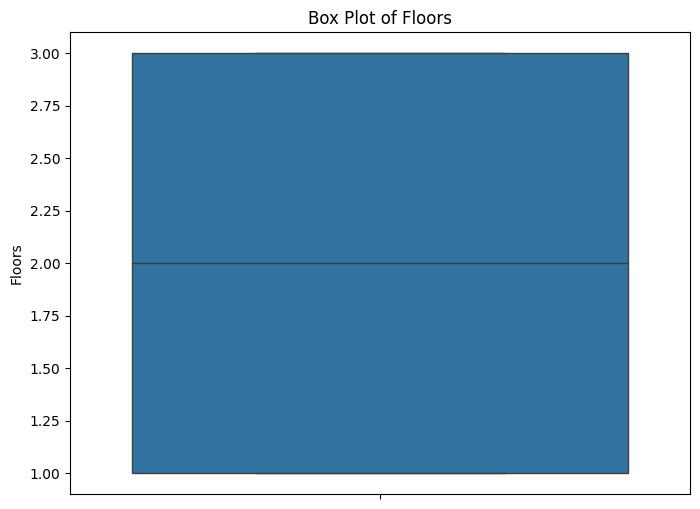

In [ ]:
#Box Plot for Floors
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Floors'])
plt.title('Box Plot of Floors')
plt.ylabel('Floors')
plt.show()

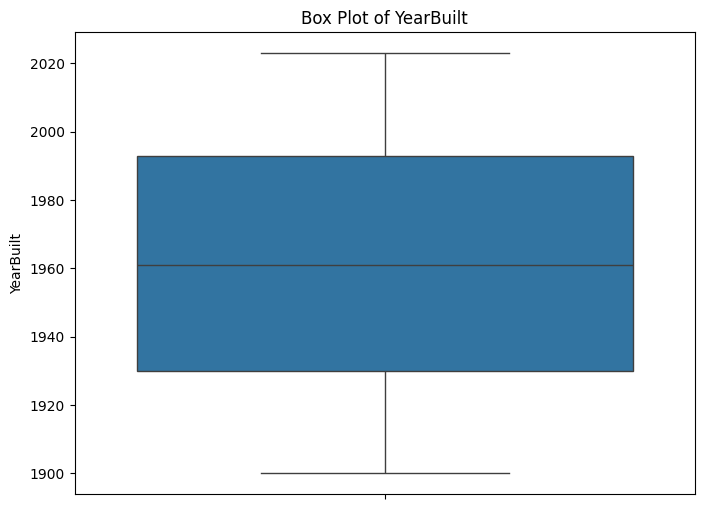

In [ ]:
#Box Plot for YearBuilt
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['YearBuilt'])
plt.title('Box Plot of YearBuilt')
plt.ylabel('YearBuilt')
plt.show()

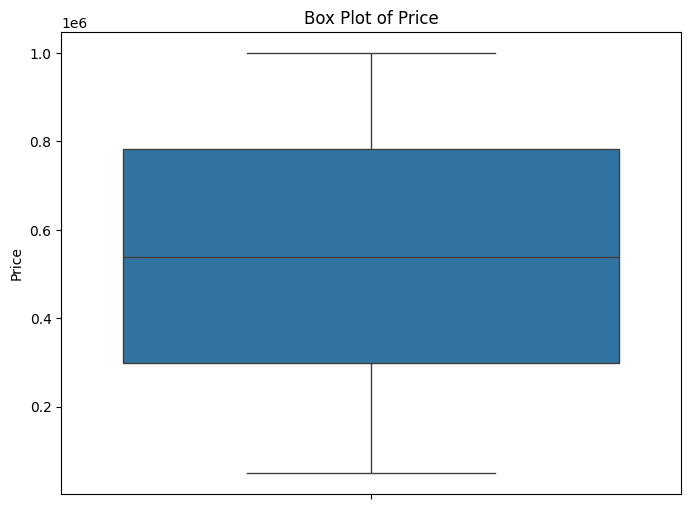

In [ ]:
#Box Plot for Price
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price')
plt.ylabel('Price')
plt.show()

In [ ]:
#Handling Outliers using IQR Method (Capping)
numerical_cols_for_outliers = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt', 'Price']
for col in numerical_cols_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    print(f"Outliers in '{col}' capped between {lower_bound:.2f} and {upper_bound:.2f}")

print('\nOutliers have been handled.')

Outliers in 'Area' capped between -1697.88 and 7241.12
Outliers in 'Bedrooms' capped between -1.00 and 7.00
Outliers in 'Bathrooms' capped between -1.00 and 7.00
Outliers in 'Floors' capped between -2.00 and 6.00
Outliers in 'YearBuilt' capped between 1835.50 and 2087.50
Outliers in 'Price' capped between -424488.25 and 1505903.75

Outliers have been handled.


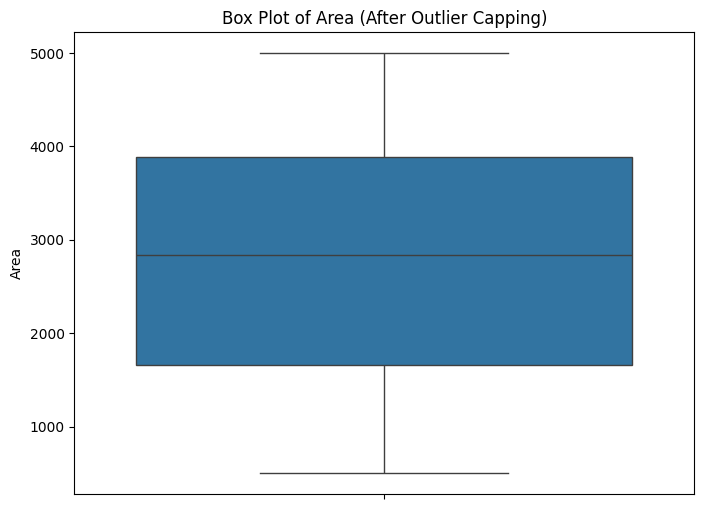

In [ ]:
#Box Plot for 'Area' after capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Area'])
plt.title('Box Plot of Area (After Outlier Capping)')
plt.ylabel('Area')
plt.show()

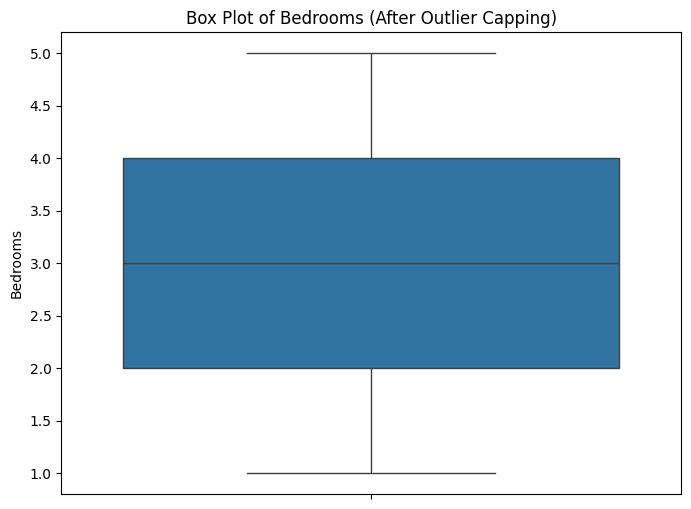

In [ ]:
#Box Plot for 'Bedrooms' after capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Bedrooms'])
plt.title('Box Plot of Bedrooms (After Outlier Capping)')
plt.ylabel('Bedrooms')
plt.show()

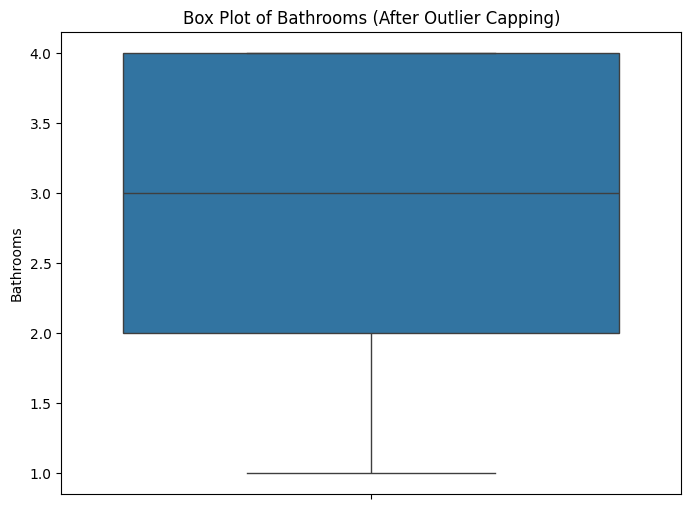

In [ ]:
#Box Plot for 'Bathrooms' after capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Bathrooms'])
plt.title('Box Plot of Bathrooms (After Outlier Capping)')
plt.ylabel('Bathrooms')
plt.show()

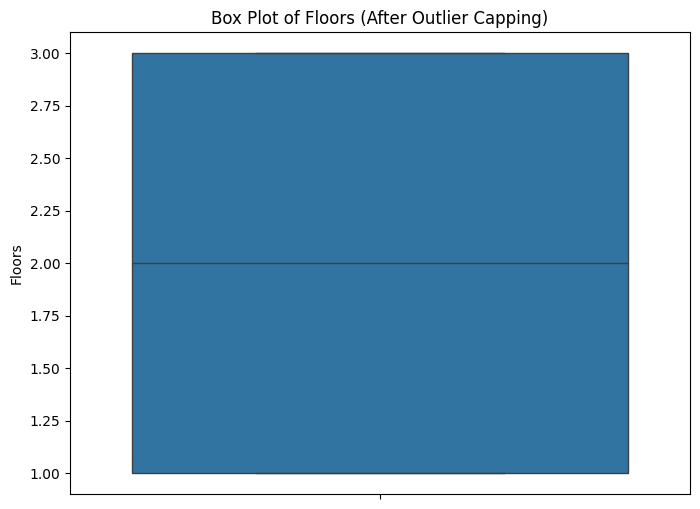

In [ ]:
#Box Plot for 'Floors' after capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Floors'])
plt.title('Box Plot of Floors (After Outlier Capping)')
plt.ylabel('Floors')
plt.show()

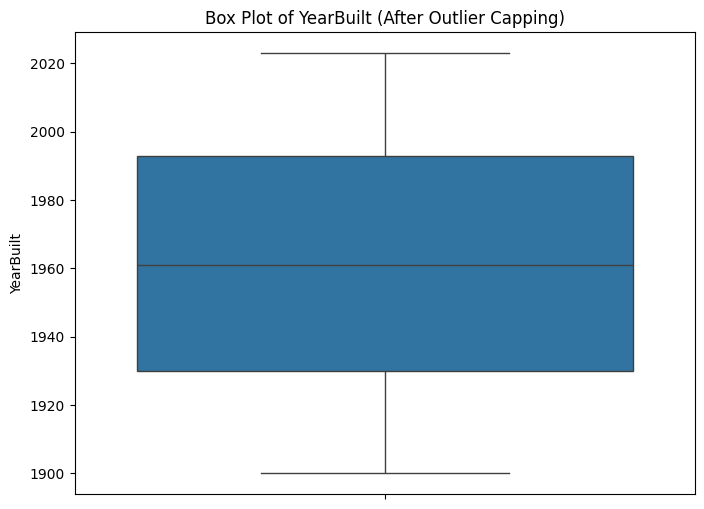

In [ ]:
#Box Plot for 'YearBuilt' after capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['YearBuilt'])
plt.title('Box Plot of YearBuilt (After Outlier Capping)')
plt.ylabel('YearBuilt')
plt.show()

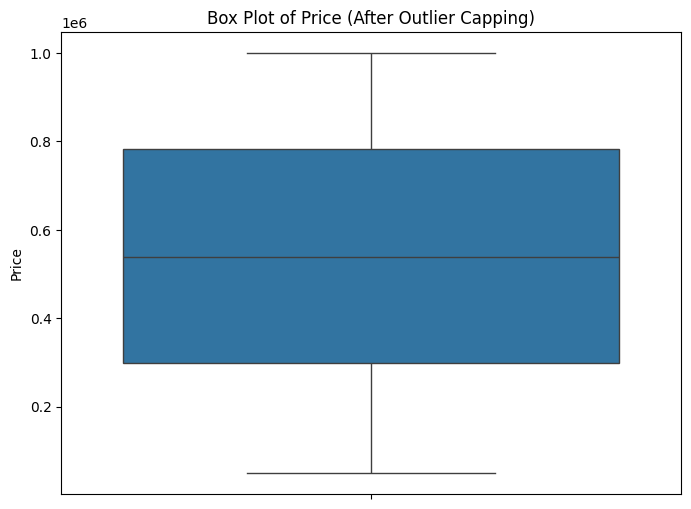

In [ ]:
#Box Plot for 'Price' after capping
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Price'])
plt.title('Box Plot of Price (After Outlier Capping)')
plt.ylabel('Price')
plt.show()

In [ ]:
# Apply one-hot encoding to 'Location' and 'Condition'
df = pd.get_dummies(df, columns=['Location', 'Condition'], dtype=float)



In [ ]:
# Convert 'Garage' to binary (Yes=1, No=0)
df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

print("Binary encoding applied to 'Garage'.")

Binary encoding applied to 'Garage'.


In [ ]:
display(df.head())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor
0,1,1360.0,5.0,4.0,3.0,1970.0,0,149919.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,4272.0,5.0,4.0,3.0,1958.0,0,424998.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,3592.0,2.0,2.0,3.0,1938.0,0,266746.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,966.0,4.0,2.0,2.0,1902.0,1,244020.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,5,4926.0,1.0,4.0,2.0,1975.0,1,636056.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


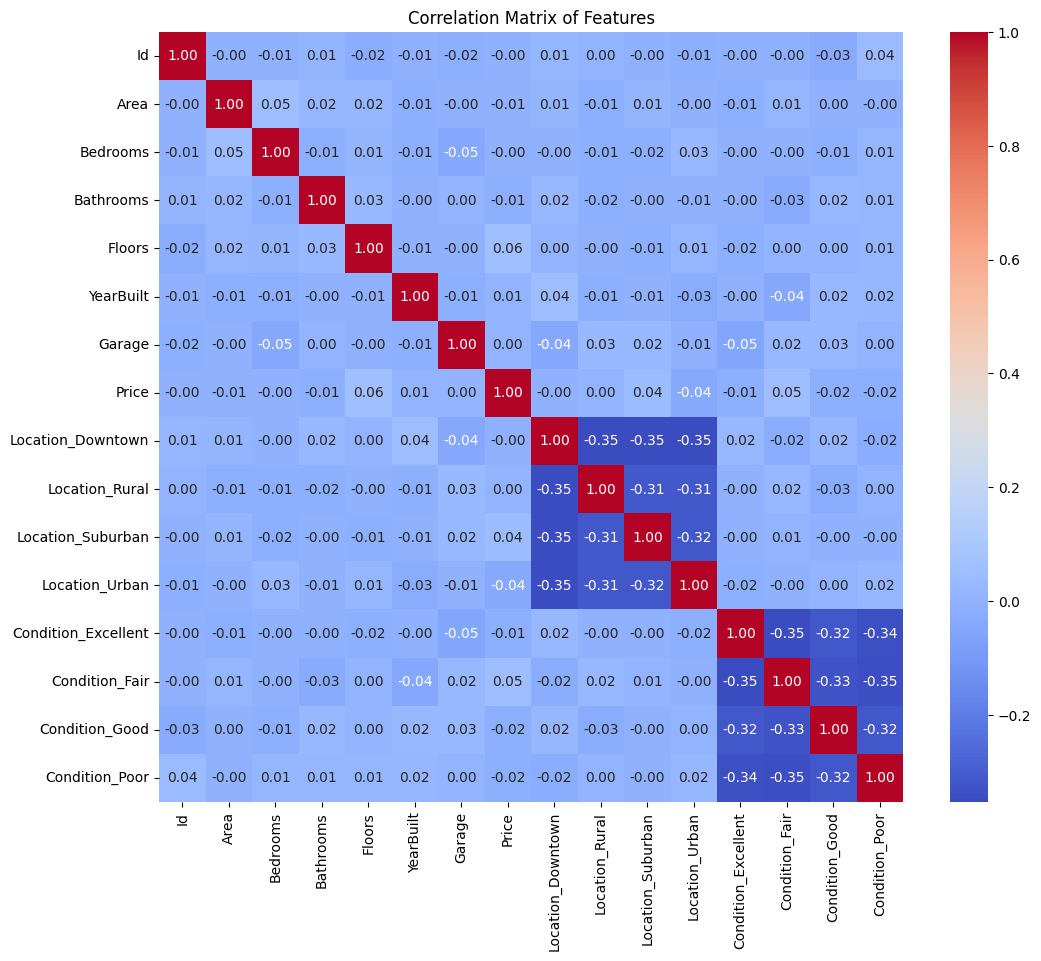

In [ ]:
#Correlation Matrix
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

/tmp/ipykernel_1217/2924866942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Garage', y='Price', data=df, palette='viridis')


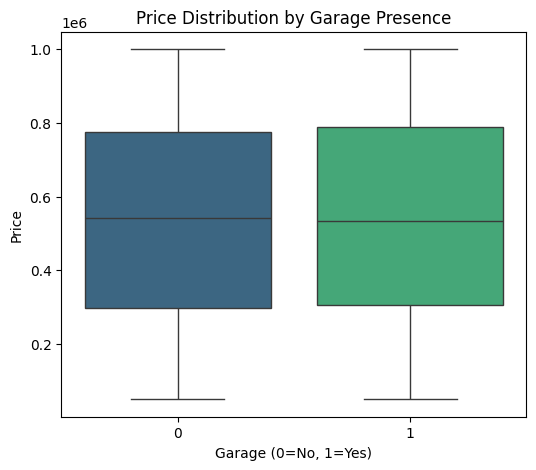

In [ ]:
# Relationship of 'Garage' with 'Price'
plt.figure(figsize=(6, 5))
sns.boxplot(x='Garage', y='Price', data=df, palette='viridis')
plt.title('Price Distribution by Garage Presence')
plt.xlabel('Garage (0=No, 1=Yes)')
plt.ylabel('Price')
plt.show()

/tmp/ipykernel_1217/3044786231.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(condition_avg_price.keys()), y=list(condition_avg_price.values()), palette='coolwarm')


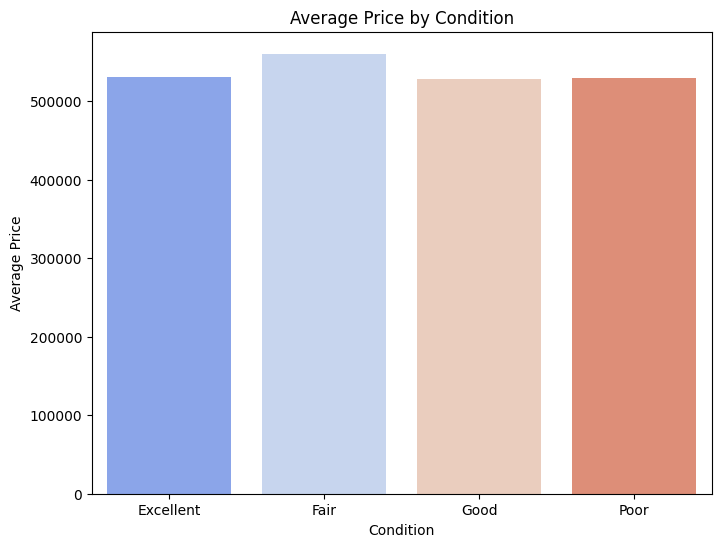

In [ ]:
# Relationship of 'Condition' with 'Price'
condition_cols = [col for col in df.columns if 'Condition_' in col]
condition_avg_price = {}
for col in condition_cols:
    condition_avg_price[col.replace('Condition_', '')] = df[df[col] == 1]['Price'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=list(condition_avg_price.keys()), y=list(condition_avg_price.values()), palette='coolwarm')
plt.title('Average Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Average Price')
plt.show()

In [ ]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

# Define the numerical features to scale (excluding 'Id' and 'Price')
numerical_features= ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt']

scaler = StandardScaler()

# Apply StandardScaler to the selected numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("Numerical features scaled successfully using StandardScaler.")

Numerical features scaled successfully using StandardScaler.


In [ ]:
display(df.head())

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Garage,Price,Location_Downtown,Location_Rural,Location_Suburban,Location_Urban,Condition_Excellent,Condition_Fair,Condition_Good,Condition_Poor
0,1,-1.101237,1.407640,1.306598,1.246428,0.239252,0,149919.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,2,1.144498,1.407640,1.306598,1.246428,-0.095073,0,424998.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3,0.620082,-0.700692,-0.501712,1.246428,-0.652281,0,266746.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,4,-1.405090,0.704862,-0.501712,0.009178,-1.655256,1,244020.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,5,1.648863,-1.403469,1.306598,0.009178,0.378555,1,636056.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# Define features (X) by dropping 'Id' and 'Price'
X = df.drop(columns=['Id', 'Price'])

# Define target (y) as 'Price'
y = df['Price']

print("Features (X) and Target (y) defined successfully.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and Target (y) defined successfully.
Shape of X: (2022, 14)
Shape of y: (2022,)


In [ ]:
#Data Splitting
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets successfully.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets successfully.
Shape of X_train: (1617, 14)
Shape of X_test: (405, 14)
Shape of y_train: (1617,)
Shape of y_test: (405,)


In [ ]:
#########START TRAINING THE MODELS FROM HERE MY PEOPLE, X and Y. ALREADY DEFINED......

using Random Forest Regressor by Ayesigwa Pleasure Mugabe

---



In [ ]:
from sklearn.ensemble import RandomForestRegressor
#creating model
model = RandomForestRegressor(
    n_estimators=100
)
# Training the model
model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [ ]:
#trying to prredict
y_pred = model.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
#importing evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [ ]:
#caculating the metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Model Evaluation Results:
MAE: 244626.43
MSE: 81507567347.50
RMSE: 285495.30
R² Score: -0.08


In [ ]:
#comparing actual price and predicted price
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

print(comparison.head(10))

   Actual Price  Predicted Price
0      697861.0        519484.23
1      233951.0        474243.89
2      710709.0        468739.92
3      240191.0        401496.31
4      756168.0        538209.21
5      448115.0        488924.49
6      589618.0        565821.54
7      820227.0        527582.10
8      965885.0        436059.84
9      601151.0        388432.30


In [ ]:
# Check feature importance from the Random Forest
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                Feature  Importance
0                  Area    0.322816
4             YearBuilt    0.252902
1              Bedrooms    0.089095
2             Bathrooms    0.072338
3                Floors    0.044584
5                Garage    0.032962
13       Condition_Poor    0.023981
12       Condition_Good    0.023749
11       Condition_Fair    0.023632
9        Location_Urban    0.023063
7        Location_Rural    0.023030
10  Condition_Excellent    0.022890
6     Location_Downtown    0.022647
8     Location_Suburban    0.022311


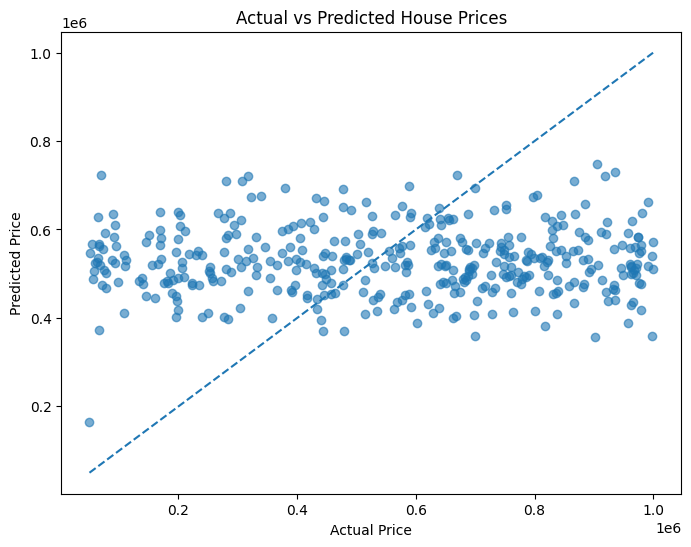

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

Using Ridge Regression by Asinja Andrew

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [ ]:
# Initialize Ridge Regression (alpha=1.0 is the default regularization parameter)
ridge_model = Ridge(alpha=1.0)

# Train the model on the training data
ridge_model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [ ]:
# Predictions on test set
y_pred = ridge_model.predict(X_test)

# Predictions on training set (for comparison)
y_train_pred = ridge_model.predict(X_train)

In [ ]:
# Compute evaluation metrics for Test set
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Compute R2 score on Training set
train_r2 = r2_score(y_train, y_train_pred)

print("=== Model Evaluation Metrics ===")
print(f"Training R² Score: {train_r2:.4f}")
print(f"Test R² Score:     {r2:.4f}")
print(f"Test MAE:          {mae:.4f}")
print(f"Test MSE:          {mse:.4f}")
print(f"Test RMSE:         {rmse:.4f}")

=== Model Evaluation Metrics ===
Training R² Score: 0.0084
Test R² Score:     -0.0046
Test MAE:          238262.6480
Test MSE:          76035892570.5751
Test RMSE:         275746.0654


In [ ]:
#comparing prices
import pandas as pd

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred,
    'Absolute Error': np.abs(y_test - y_pred),
    'Percentage Error (%)': np.abs((y_test - y_pred) / y_test) * 100
})

# Display first 15 rows
comparison_df.head(15).round(2)

,Actual Price,Predicted Price,Absolute Error,Percentage Error (%)
674,697861.0,551924.42,145936.58,20.91
1384,233951.0,538702.13,304751.13,130.26
720,710709.0,553279.56,157429.44,22.15
590,240191.0,556942.96,316751.96,131.88
576,756168.0,526040.37,230127.63,30.43
1285,448115.0,509740.18,61625.18,13.75
128,589618.0,565757.02,23860.98,4.05
1456,820227.0,551873.70,268353.30,32.72
1302,965885.0,550886.02,414998.98,42.97
1887,601151.0,528968.00,72183.00,12.01


In [ ]:
#summary statistics on errors
print("=== Price Prediction Breakdown ===")
print(f"Average Actual Price:    ${y_test.mean():,.2f}")
print(f"Average Predicted Price: ${y_pred.mean():,.2f}")
print(f"Median Absolute Error:   ${comparison_df['Absolute Error'].median():,.2f}")
print(f"Max Over-prediction:     ${(y_pred - y_test).max():,.2f}")
print(f"Max Under-prediction:    ${(y_test - y_pred).max():,.2f}")

=== Price Prediction Breakdown ===
Average Actual Price:    $556,406.79
Average Predicted Price: $533,365.85
Median Absolute Error:   $237,743.05
Max Over-prediction:     $501,096.93
Max Under-prediction:    $496,846.90


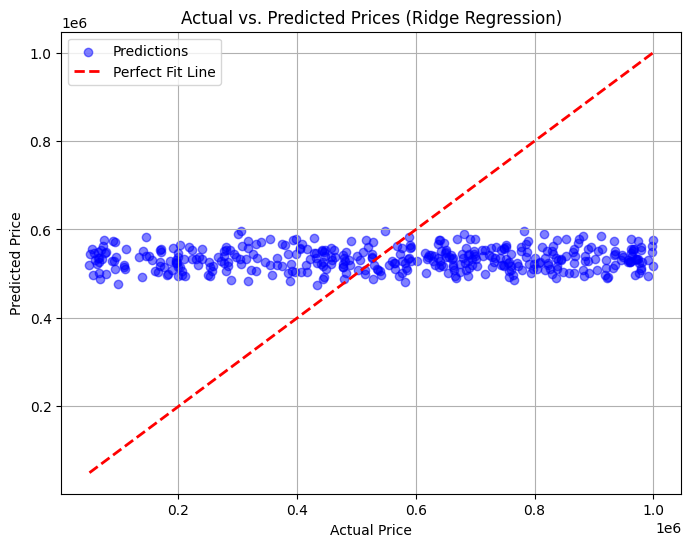

In [ ]:
#visualization of actual vs. predicted prices
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit Line')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted Prices (Ridge Regression)')
plt.legend()
plt.grid(True)
plt.show()

Ridge Regressor Evaluation Report

Model Setup & Experimental Design:

The dataset was partitioned using an 80/20 train-test split, reserving 80% of the observations to train the Ridge Regression model ($L_2$ regularization) and 20% to assess generalization on unseen target values.

Quantitative Metrics Summary
Training $R^2$ Score ($0.0084$): Explains only ~0.84% of variance in the training set, signalling severe underfitting.

Test $R^2$ Score ($-0.0046$): Underperforms a baseline horizontal line (mean target estimator) on unseen test data.

Mean Absolute Error ($238,262.65$): On average, predictions deviate from actual values by roughly $238,262.65$ units.

Root Mean Squared Error ($275,746.07$): Penalizes larger error magnitudes, indicating significant variance in prediction residuals.   

Mean Squared Error ($76,035,892,570.58$): Total variance of raw squared residuals across all test instances.   

Detailed Performance Analysis & Diagnostic Insights
1. Underfitting & Low Predictive Capability:The baseline Ridge Regression model exhibits poor predictive performance. Both training ($0.0084$) and test ($-0.0046$) $R^2$ metrics confirm that linear penalization without feature transformation fails to capture underlying patterns.   

2. Residual Discrepancy (RMSE vs. MAE):The notable gap between the MAE ($\approx 238,262.65$) and RMSE ($\approx 275,746.07$) highlights that prediction errors are not uniformly distributed. A subset of high-value target outliers is incurring substantial residual penalties.

This result serves as the primary Ridge Regression baseline.